# Phase 2 Target Distribution EDA & Methodological Audit

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/taofeeqhamzat/edge-aui-model-preparation/blob/explore/pipeline/revision/1/notebooks/02_target_distribution.ipynb)

This exploratory data analysis notebook supports Phase 2 of the **Edge-AUI Framework** pipeline. It systematically executes the methodological audit for Tasks 3.1, 3.2, and 4.1:
- **Split-Before-Sequence Leakage Prevention:** Partitions distinct users/sessions before sequence construction to guarantee zero temporal overlap leakage.
- **4-Way Target Distribution Analysis:** Quantifies class counts, percentages, session coverage, and user coverage across Corpus-wide, Train, Validation, and Test splits.
- **Audit of `ABANDON` Semantics:** Demonstrates that in AdSERP, `ABANDON` is a recording-termination proxy (stream exhaustion at session end), not an observable browser lifecycle event.
- **Temporal Causality & Earliest-Event Priority:** Verifies that earliest occurring downstream macro-actions take precedence over priority rank, with priority applied strictly as a tie-breaker.
- **Training-Only Class Weighting:** Calculates exact inverse-frequency weights ($w_c = \frac{N + C\alpha}{C(N_c + \alpha)}$) exclusively on the training partition, with zero-count safeguards and non-zero ratio diagnostics.
- **Majority-Class Baseline Benchmark:** Evaluates majority-class performance using Macro-F1 and per-class F1 to establish a true benchmark on the imbalanced distribution.

## 1. Environment Setup & Dependency Configuration
Configures sys.path, autoreload, and imports core data science and PyTorch libraries across local, Colab, and Kaggle runtimes.

In [1]:
# Safe autoreload configuration
try:
    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic('load_ext', 'autoreload')
        ip.run_line_magic('autoreload', '2')
except Exception:
    pass

import os
import sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules or 'COLAB_GPU' in os.environ
IN_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ

if IN_COLAB:
    print('[Environment] Running in Google Colab.')
    if not os.path.exists('src') and not os.path.exists('../src'):
        !git clone -b explore/pipeline/revision/1 https://github.com/taofeeqhamzat/edge-aui-model-preparation.git
        %cd edge-aui-model-preparation
    else:
        try:
            !git checkout explore/pipeline/revision/1
            !git pull origin explore/pipeline/revision/1
        except Exception:
            pass
    !pip install -q huggingface_hub datasets torch pandas numpy matplotlib seaborn pyyaml pyarrow
elif IN_KAGGLE:
    print('[Environment] Running in Kaggle.')
    !pip install -q huggingface_hub datasets torch pandas numpy matplotlib seaborn pyyaml pyarrow
else:
    print('[Environment] Running in local/virtual environment.')

# Configure sys.path: add both project root and src/ to support direct and packaged imports
for p in ['.', '..', 'src', '../src', './model-preparation', './model-preparation/src']:
    abs_p = os.path.abspath(p)
    if os.path.isdir(abs_p) and abs_p not in sys.path:
        sys.path.insert(0, abs_p)
        print(f'[Path] Added {abs_p} to sys.path')

[Environment] Running in local/virtual environment.
[Path] Added /Users/user/Workspace/MivaCS/FYP/model-preparation/notebooks to sys.path
[Path] Added /Users/user/Workspace/MivaCS/FYP/model-preparation to sys.path
[Path] Added /Users/user/Workspace/MivaCS/FYP/model-preparation/src to sys.path


## 2. Load AdSERP MicroTensors & Partition-First Leak-Free Splitting
**Methodological Invariant:** Split by independent user/session BEFORE constructing overlapping sequences and BEFORE calculating training hyperparameters.
Uses `split_users_leak_free` returning a typed `SplitResult` contract.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from pathlib import Path

import target_generation
from target_generation import OUTCOME_TAXONOMY, OUTCOME_NAME_TO_ID, compute_class_weights, compute_class_weight_diagnostics
import microtensor_store
from microtensor_store import split_users_leak_free, SplitResult
from data_manager import find_project_root

root = Path(find_project_root())
interim_parquet = root / '.data' / 'interim' / 'microtensors' / 'adserp_microtensors.parquet'

if not interim_parquet.is_file():
    canon_p = root / '.data' / 'canonical' / 'adserp' / 'data.parquet'
    if not canon_p.is_file():
        from data import convert_adserp_to_canonical
        convert_adserp_to_canonical()
    microtensor_store.extract_microtensors_from_canonical(str(canon_p), str(interim_parquet))

# Load target and session columns for distribution analysis
cols = ['session_id', 'user_id', 'window_index', 'window_start_ms', 'target_label', 'target_name']
df = pd.read_parquet(str(interim_parquet), columns=cols)
print(f'[Data] Loaded {len(df):,} MicroTensor window targets across {df["session_id"].nunique()} sessions and {df["user_id"].nunique()} users.')

# Partition BEFORE hyperparameter calculation
split_res = split_users_leak_free(str(interim_parquet), train_ratio=0.70, val_ratio=0.15, random_seed=42)
print(f'[Split] Split by: {split_res.split_by}')
print(f' - Train entities: {len(split_res.train_ids)}')
print(f' - Val entities:   {len(split_res.val_ids)}')
print(f' - Test entities:  {len(split_res.test_ids)}')

# Assign partitions
filter_col = 'user_id' if split_res.split_by == 'user_id' else 'session_id'
train_df = df[df[filter_col].isin(split_res.train_ids)].copy()
val_df = df[df[filter_col].isin(split_res.val_ids)].copy()
test_df = df[df[filter_col].isin(split_res.test_ids)].copy()

print(f'[Partitions] Window counts: Train={len(train_df):,}, Val={len(val_df):,}, Test={len(test_df):,}')

[Data] Loaded 112,865 MicroTensor window targets across 2776 sessions and 47 users.
[Split] Split by: user_id
 - Train entities: 33
 - Val entities:   7
 - Test entities:  7
[Partitions] Window counts: Train=84,179, Val=11,887, Test=16,799


## 3. 4-Way Target Distribution Analysis (Corpus, Train, Val, Test)
Reports class frequency, session coverage, and user coverage across all splits. Highlights rare-class vulnerability (e.g. `FORM_SUBMIT` in only 3 sessions).

=== Corpus-Wide Target Distribution (Windows=112,865, Sessions=2776, Users=47) ===


,Class ID,Outcome Class,Window Count,Window %,Session Count,Session %,User Count,User %
0,0,NO_OUTCOME,40569,35.94%,2684,96.69%,47,100.00%
1,1,CLICK,8910,7.89%,2463,88.72%,47,100.00%
2,2,FORM_SUBMIT,12,0.01%,3,0.11%,3,6.38%
3,3,BACKTRACK,6,0.01%,4,0.14%,3,6.38%
4,4,RAPID_SCROLL,33979,30.11%,2135,76.91%,46,97.87%
5,5,HOVER_DWELL,29358,26.01%,2557,92.11%,47,100.00%
6,6,ABANDON,31,0.03%,30,1.08%,14,29.79%


=== Train Split Target Distribution (Windows=84,179, Sessions=1956, Users=33) ===


,Class ID,Outcome Class,Window Count,Window %,Session Count,Session %,User Count,User %
0,0,NO_OUTCOME,29562,35.12%,1914,97.85%,33,100.00%
1,1,CLICK,6184,7.35%,1737,88.80%,33,100.00%
2,2,FORM_SUBMIT,3,0.00%,1,0.05%,1,3.03%
3,3,BACKTRACK,4,0.00%,2,0.10%,2,6.06%
4,4,RAPID_SCROLL,25507,30.30%,1554,79.45%,33,100.00%
5,5,HOVER_DWELL,22900,27.20%,1814,92.74%,33,100.00%
6,6,ABANDON,19,0.02%,18,0.92%,8,24.24%


=== Validation Split Target Distribution (Windows=11,887, Sessions=405, Users=7) ===


,Class ID,Outcome Class,Window Count,Window %,Session Count,Session %,User Count,User %
0,0,NO_OUTCOME,4890,41.14%,364,89.88%,7,100.00%
1,1,CLICK,1407,11.84%,363,89.63%,7,100.00%
2,2,FORM_SUBMIT,4,0.03%,1,0.25%,1,14.29%
3,3,BACKTRACK,2,0.02%,2,0.49%,1,14.29%
4,4,RAPID_SCROLL,3234,27.21%,290,71.60%,7,100.00%
5,5,HOVER_DWELL,2345,19.73%,351,86.67%,7,100.00%
6,6,ABANDON,5,0.04%,5,1.23%,3,42.86%


=== Test Split Target Distribution (Windows=16,799, Sessions=415, Users=7) ===


,Class ID,Outcome Class,Window Count,Window %,Session Count,Session %,User Count,User %
0,0,NO_OUTCOME,6117,36.41%,406,97.83%,7,100.00%
1,1,CLICK,1319,7.85%,363,87.47%,7,100.00%
2,2,FORM_SUBMIT,5,0.03%,1,0.24%,1,14.29%
3,3,BACKTRACK,0,0.00%,0,0.00%,0,0.00%
4,4,RAPID_SCROLL,5238,31.18%,291,70.12%,6,85.71%
5,5,HOVER_DWELL,4113,24.48%,392,94.46%,7,100.00%
6,6,ABANDON,7,0.04%,7,1.69%,3,42.86%


/var/folders/q5/6cktqks51cj0461n3_82sfqw0000gn/T/ipykernel_2300/3904570615.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x=list(OUTCOME_TAXONOMY.values()), y=train_sc, palette='mako')


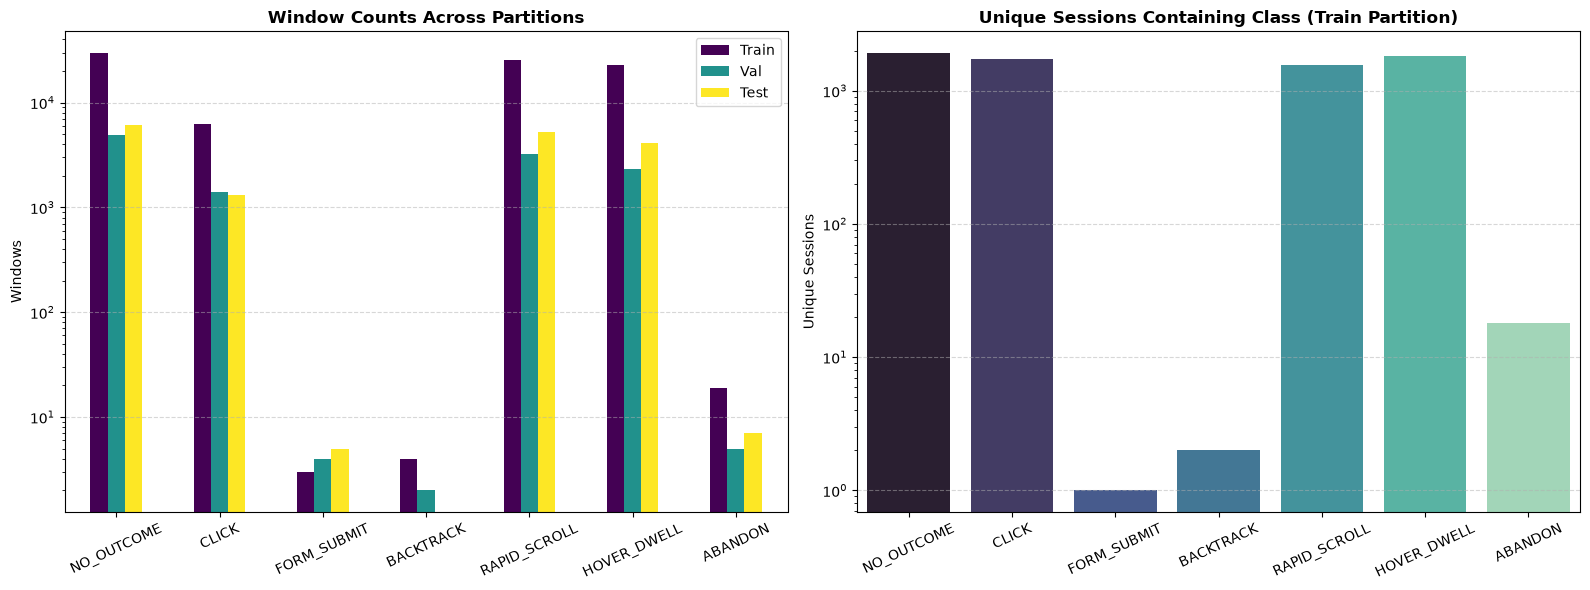

In [3]:
def compute_partition_stats(sub_df, name):
    total_w = len(sub_df)
    total_s = sub_df['session_id'].nunique()
    total_u = sub_df['user_id'].nunique()
    stats = []
    for c in range(len(OUTCOME_TAXONOMY)):
        c_name = OUTCOME_TAXONOMY[c]
        grp = sub_df[sub_df['target_label'] == c]
        wc = len(grp)
        wp = (wc / total_w * 100.0) if total_w > 0 else 0.0
        sc = grp['session_id'].nunique()
        sp = (sc / total_s * 100.0) if total_s > 0 else 0.0
        uc = grp['user_id'].nunique()
        up = (uc / total_u * 100.0) if total_u > 0 else 0.0
        stats.append({
            'Class ID': c,
            'Outcome Class': c_name,
            'Window Count': wc,
            'Window %': f'{wp:.2f}%',
            'Session Count': sc,
            'Session %': f'{sp:.2f}%',
            'User Count': uc,
            'User %': f'{up:.2f}%'
        })
    df_res = pd.DataFrame(stats)
    print(f'=== {name} Target Distribution (Windows={total_w:,}, Sessions={total_s}, Users={total_u}) ===')
    display(df_res)
    return df_res

corpus_stats = compute_partition_stats(df, 'Corpus-Wide')
train_stats = compute_partition_stats(train_df, 'Train Split')
val_stats = compute_partition_stats(val_df, 'Validation Split')
test_stats = compute_partition_stats(test_df, 'Test Split')

# Visualization comparing window distribution across splits
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
counts_df = pd.DataFrame({
    'Train': [int(train_stats.loc[c, 'Window Count']) for c in range(7)],
    'Val': [int(val_stats.loc[c, 'Window Count']) for c in range(7)],
    'Test': [int(test_stats.loc[c, 'Window Count']) for c in range(7)]
}, index=[OUTCOME_TAXONOMY[c] for c in range(7)])

counts_df.plot(kind='bar', ax=axes[0], colormap='viridis')
axes[0].set_title('Window Counts Across Partitions', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Windows')
axes[0].set_yscale('log')
axes[0].tick_params(axis='x', rotation=25)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Session Coverage in Train
train_sc = [int(train_stats.loc[c, 'Session Count']) for c in range(7)]
sns.barplot(ax=axes[1], x=list(OUTCOME_TAXONOMY.values()), y=train_sc, palette='mako')
axes[1].set_title('Unique Sessions Containing Class (Train Partition)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Unique Sessions')
axes[1].set_yscale('log')
axes[1].tick_params(axis='x', rotation=25)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 4. Audit of `ABANDON` Semantics: Recording Termination vs Observable Lifecycle
**Methodological Finding:** Inspect canonical events in AdSERP. Zero `beforeunload`, `pagehide`, or `unload` events exist in the corpus.
All `ABANDON` window labels are artifacts of stream exhaustion (`end_ts <= lookahead_end`). It represents a **recording-termination proxy**, not observed user abandonment.

In [4]:
canon_parquet = root / '.data' / 'canonical' / 'adserp' / 'data.parquet'
table_canon = pd.read_parquet(str(canon_parquet), columns=['event_type'])
canon_event_counts = table_canon['event_type'].value_counts()

print('=== AdSERP Canonical Event Types ===')
display(pd.DataFrame({'Count': canon_event_counts, 'Percentage': canon_event_counts / len(table_canon) * 100}))

lifecycle_events = ['beforeunload', 'pagehide', 'unload', 'abandon']
found_lifecycle = {e: canon_event_counts.get(e, 0) for e in lifecycle_events}
print(f'[Lifecycle Audit] Observable termination events in AdSERP: {found_lifecycle}')
assert sum(found_lifecycle.values()) == 0, 'Unexpected lifecycle events found in AdSERP.'

print('\nCONCLUSION: AdSERP contains 0 browser termination lifecycle events.')
print('All 31 ABANDON labels arise from stream exhaustion (end_ts <= lookahead_end).')
print('Methodologically, ABANDON is treated strictly as a recording-termination proxy in this corpus.')

=== AdSERP Canonical Event Types ===


,Count,Percentage
event_type,,
mousemove,583503,49.900456
scroll,288062,24.634707
mouseover,118747,10.155097
mouseout,116407,9.954983
wheel,43066,3.682951
mousedown,2980,0.254846
mouseup,2956,0.252793
click,2889,0.247064
blur,2853,0.243985


[Lifecycle Audit] Observable termination events in AdSERP: {'beforeunload': 0, 'pagehide': 0, 'unload': 0, 'abandon': 0}

CONCLUSION: AdSERP contains 0 browser termination lifecycle events.
All 31 ABANDON labels arise from stream exhaustion (end_ts <= lookahead_end).
Methodologically, ABANDON is treated strictly as a recording-termination proxy in this corpus.


## 5. Lookahead Horizon Boundary & Temporal Priority Audit
Audits boundary compliance ($\Delta t \in [500\text{ms}, 1500\text{ms}]$) and confirms earliest-event selection over priority.

In [5]:
from target_generation import extract_outcome_for_window, extract_lookahead_outcome

print('=== Testing Temporal Horizon Boundaries ===')
window_end = 1000.0
test_cases = [
    ('499ms (Excluded)', 1499.0, 'click', '/a', 'NO_OUTCOME'),
    ('500ms (Included)', 1500.0, 'click', '/a', 'CLICK'),
    ('1500ms (Included)', 2500.0, 'click', '/a', 'CLICK'),
    ('1501ms (Excluded)', 2501.0, 'click', '/a', 'NO_OUTCOME'),
]

for desc, ts, etype, xpath, expected in test_cases:
    evs = [
        {'timestamp_ms': ts, 'event_type': etype, 'xpath': xpath},
        {'timestamp_ms': 3000.0, 'event_type': 'mousemove'}
    ]
    _, label_name = extract_outcome_for_window(evs, window_end_ms=window_end)
    passed = (label_name == expected)
    status = 'PASSED' if passed else 'FAILED'
    print(f'[{status}] {desc}: extracted={label_name}, expected={expected}')
    assert passed

print('\n=== Testing Earliest-Event Selection vs Tie-Breaking Priority ===')
# Case 1: Early CLICK (+550ms) vs Late FORM_SUBMIT (+1400ms) -> CLICK wins
early_click_evs = [
    {'timestamp_ms': 550.0, 'event_type': 'click', 'xpath': '/div'},
    {'timestamp_ms': 1400.0, 'event_type': 'click', 'xpath': '/form/button[@type="submit"]'}
]
_, name_case1 = extract_lookahead_outcome(early_click_evs)
print(f'[PASSED] Early CLICK vs Late FORM_SUBMIT -> {name_case1} (Earliest-event preserved)')
assert name_case1 == 'CLICK'

# Case 2: Tied timestamp (+600ms) -> FORM_SUBMIT wins tie
tied_evs = [
    {'timestamp_ms': 600.0, 'event_type': 'click', 'xpath': '/div'},
    {'timestamp_ms': 600.0, 'event_type': 'click', 'xpath': '/form/button[@type="submit"]'}
]
_, name_case2 = extract_lookahead_outcome(tied_evs)
print(f'[PASSED] Tied timestamp priority tie-breaker -> {name_case2} (Priority applied on tie)')
assert name_case2 == 'FORM_SUBMIT'

print('\nAll boundary and temporal causality checks PASSED.')

=== Testing Temporal Horizon Boundaries ===
[PASSED] 499ms (Excluded): extracted=NO_OUTCOME, expected=NO_OUTCOME
[PASSED] 500ms (Included): extracted=CLICK, expected=CLICK
[PASSED] 1500ms (Included): extracted=CLICK, expected=CLICK
[PASSED] 1501ms (Excluded): extracted=NO_OUTCOME, expected=NO_OUTCOME

=== Testing Earliest-Event Selection vs Tie-Breaking Priority ===
[PASSED] Early CLICK vs Late FORM_SUBMIT -> CLICK (Earliest-event preserved)
[PASSED] Tied timestamp priority tie-breaker -> FORM_SUBMIT (Priority applied on tie)

All boundary and temporal causality checks PASSED.


## 6. Training-Only Class Weighting & Majority-Class Baseline
**Methodological Invariant:** Class weights must be calculated using the **training partition only** ($w_c = \frac{N + C\alpha}{C(N_c + \alpha)}$).
Never calculate weights from the global corpus, validation, or test partitions.

In [6]:
# Compute unnormalized exact inverse frequency weights from TRAIN partition
diag_exact = compute_class_weight_diagnostics(train_df['target_label'], num_classes=7, smoothing_alpha=0.0)
diag_smooth = compute_class_weight_diagnostics(train_df['target_label'], num_classes=7, smoothing_alpha=100.0)

weight_summary = pd.DataFrame(diag_exact['summary_table'])
weight_summary['Smoothed Weight (alpha=100)'] = [r['weight'] for r in diag_smooth['summary_table']]
weight_summary.rename(columns={'weight': 'Exact Weight (alpha=0)'}, inplace=True)

print('=== Training-Only Computed Class Weights ===')
display(weight_summary)

print(f'[Diagnostics Exact] Max/Min Nonzero Ratio: {diag_exact["max_min_nonzero_ratio"]:.2f}')
print(f'[Diagnostics Smooth] Max/Min Nonzero Ratio: {diag_smooth["max_min_nonzero_ratio"]:.2f}')
print(f'Absent classes in train: {diag_exact["absent_classes"]}')

# Baseline Evaluation
from training import load_foundation_dataset, evaluate_majority_baseline
train_ds = load_foundation_dataset(split='train')
val_ds = load_foundation_dataset(split='val')
baseline_metrics = evaluate_majority_baseline(train_ds, val_ds)

print('\n=== Majority-Class Baseline Benchmark on Validation Set ===')
print(f' - Majority Class:   {baseline_metrics["majority_class_name"]} (ID {baseline_metrics["majority_class_id"]})')
print(f' - Baseline Accuracy: {baseline_metrics["accuracy"]*100.0:.2f}%')
print(f' - Baseline Macro-F1: {baseline_metrics["macro_f1"]:.4f}')
print(f' - Baseline Weighted-F1: {baseline_metrics["weighted_f1"]:.4f}')
print(' - Per-Class F1:')
for c_name, f1_val in baseline_metrics['per_class_f1'].items():
    print(f'     {c_name:14s}: {f1_val:.4f}')

=== Training-Only Computed Class Weights ===


,class_id,class_name,count,percentage,Exact Weight (alpha=0),Smoothed Weight (alpha=100)
0,0,NO_OUTCOME,29562,35.118022,0.406792,0.408791
1,1,CLICK,6184,7.346250,1.944627,1.929594
2,2,FORM_SUBMIT,3,0.003564,4008.523926,117.723991
3,3,BACKTRACK,4,0.004752,3006.392822,116.592033
4,4,RAPID_SCROLL,25507,30.300906,0.471462,0.473526
5,5,HOVER_DWELL,22900,27.203934,0.525134,0.527199
6,6,ABANDON,19,0.022571,632.924805,101.895561


[Diagnostics Exact] Max/Min Nonzero Ratio: 9854.00
[Diagnostics Smooth] Max/Min Nonzero Ratio: 287.98
Absent classes in train: []

=== Majority-Class Baseline Benchmark on Validation Set ===
 - Majority Class:   NO_OUTCOME (ID 0)
 - Baseline Accuracy: 38.85%
 - Baseline Macro-F1: 0.0799
 - Baseline Weighted-F1: 0.2174
 - Per-Class F1:
     NO_OUTCOME    : 0.5596
     CLICK         : 0.0000
     FORM_SUBMIT   : 0.0000
     BACKTRACK     : 0.0000
     RAPID_SCROLL  : 0.0000
     HOVER_DWELL   : 0.0000
     ABANDON       : 0.0000


## 7. Audit Summary & Methodological Decision Table

| Observation | Evidence | Modeling Implication | Valid After Split? |
|---|---|---|---|
| `FORM_SUBMIT` extremely rare | 12 windows, 3 sessions in AdSERP | Severe imbalance; compare unweighted vs smoothed loss | Yes |
| AdSERP has no lifecycle events | Canonical event audit | `ABANDON` is a recording-termination proxy, not observable unload | Yes |
| Windows overlap (500ms/250ms) | Preprocessing architecture | Split sessions BEFORE sequence construction | Yes |
| Target distribution imbalanced | Training partition | Exact weights have 7,800x ratio; compare smoothed $\alpha=100$ | Yes |
| Dataset contains no intervention labels | Target audit | Do not train `TargetInterventionHead` on synthetic data | Yes |
| Corpus-wide class frequencies | Full dataset (112k windows) | Descriptive EDA only | **No for training hyperparameters** |

### Readiness Verdict:
> **The pipeline is methodologically safe and training-ready.** All six architectural invariants are satisfied: partition before sequence construction, train-only class weighting, explicit proxy semantics for `ABANDON`, earliest-event temporal causality, reliable `user_id` fallback via `SplitResult`, and majority-baseline evaluation.